In [1]:
import pandas as pd

df = pd.read_csv("Churn_Modelling.csv")

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and columns: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
print("Dataset Information")
print("=" * 50)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information
Number of rows: 10000
Number of columns: 14

Column Names:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data Types:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing Values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate

In [3]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [4]:
print("Customer Churn Distribution")
print("=" * 40)

print(df["Exited"].value_counts())

print("\nChurn Percentage")
print("=" * 40)

print((df["Exited"].value_counts(normalize=True) * 100).round(2))

Customer Churn Distribution
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Percentage
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [5]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

Missing Values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Number of Duplicate Rows:
0


In [6]:
# Remove columns that are not useful for predicting customer churn
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

print("Columns after removing unnecessary columns:")
print(df.columns.tolist())

print("\nNew dataset shape:", df.shape)

Columns after removing unnecessary columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

New dataset shape: (10000, 11)


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the customer data and identify patterns and relationships associated with customer churn.

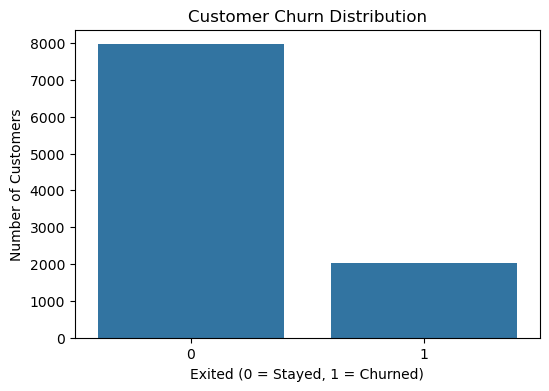

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Exited")

plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.show()

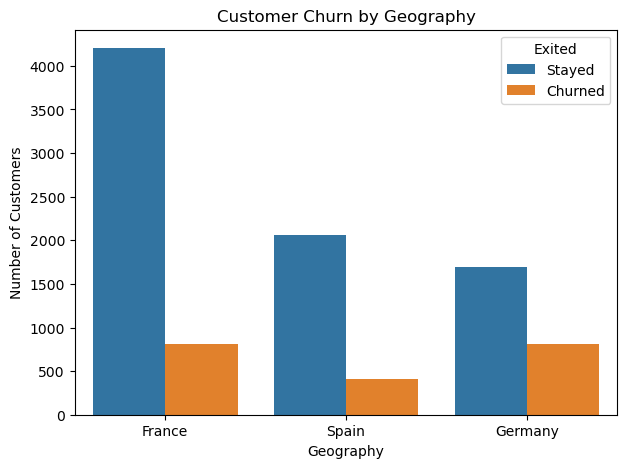

In [8]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Geography", hue="Exited")

plt.title("Customer Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Number of Customers")
plt.legend(title="Exited", labels=["Stayed", "Churned"])

plt.show()

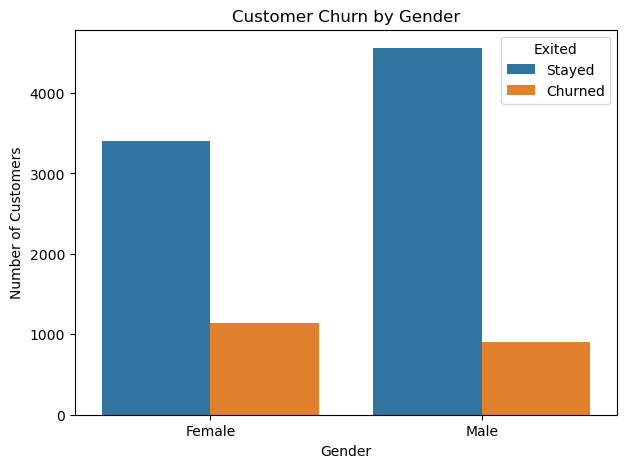

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Gender", hue="Exited")

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Exited", labels=["Stayed", "Churned"])

plt.show()

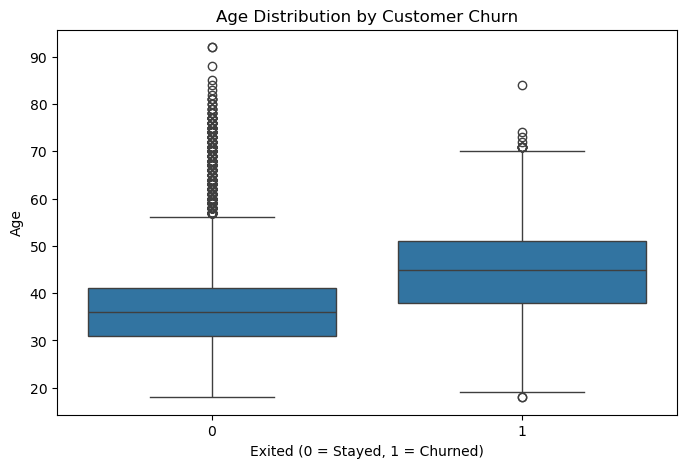

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Exited", y="Age")

plt.title("Age Distribution by Customer Churn")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Age")

plt.show()

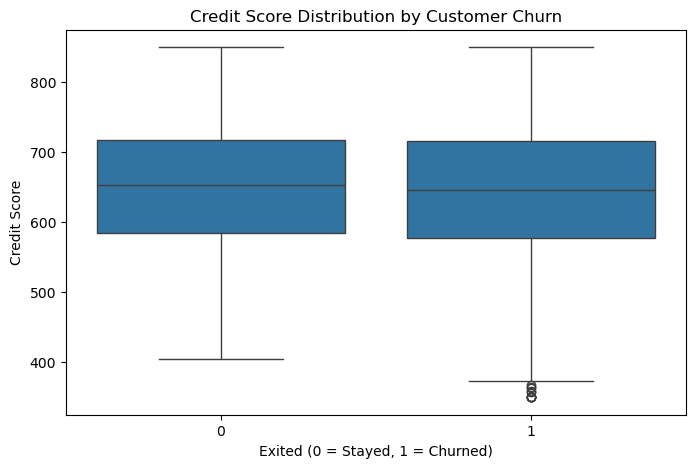

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Exited", y="CreditScore")

plt.title("Credit Score Distribution by Customer Churn")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Credit Score")

plt.show()

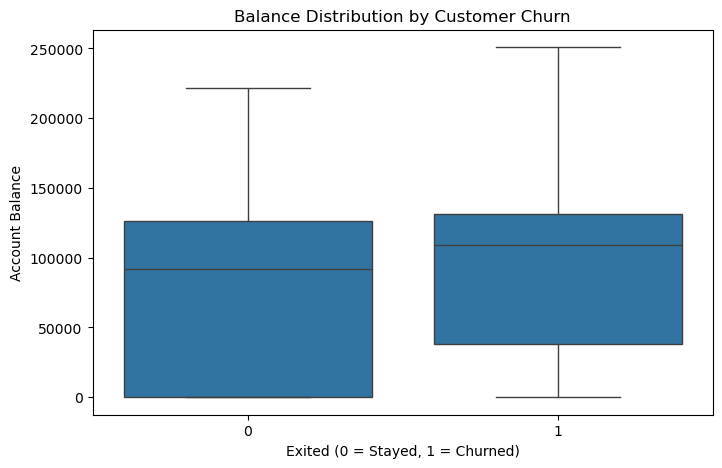

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Exited", y="Balance")

plt.title("Balance Distribution by Customer Churn")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Account Balance")

plt.show()

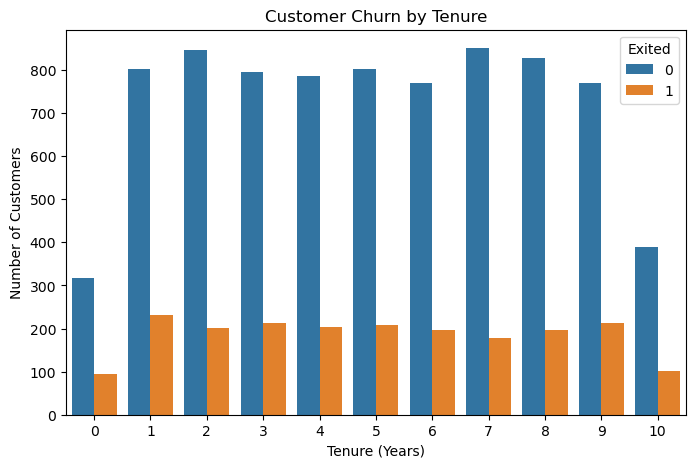

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Tenure", hue="Exited")

plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure (Years)")
plt.ylabel("Number of Customers")

plt.show()

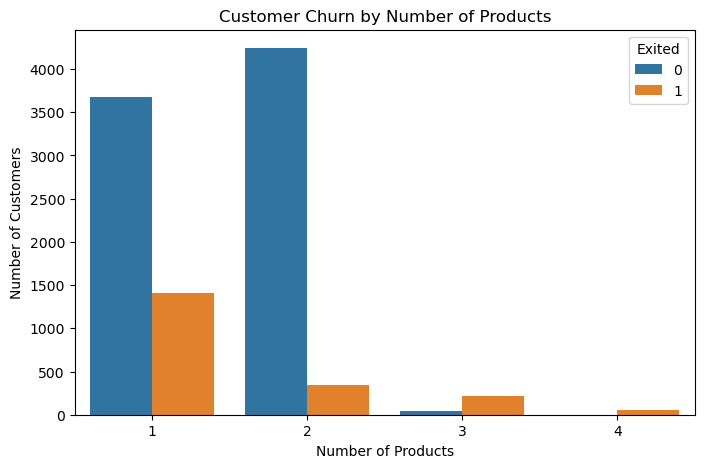

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="NumOfProducts", hue="Exited")

plt.title("Customer Churn by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")

plt.show()

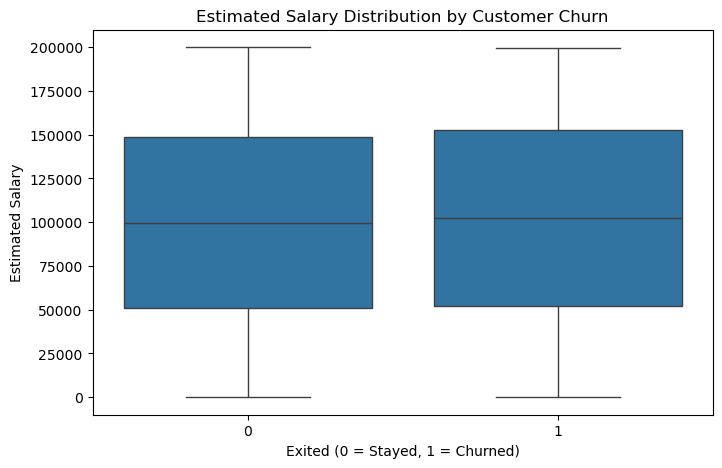

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Exited", y="EstimatedSalary")

plt.title("Estimated Salary Distribution by Customer Churn")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Estimated Salary")

plt.show()

## Data Preprocessing for Machine Learning

The dataset contains categorical variables such as Geography and Gender. These variables must be converted into numerical form before training machine learning models.

In [16]:
# Convert categorical variables into numerical variables

df_encoded = pd.get_dummies(
    df,
    columns=["Geography", "Gender"],
    drop_first=True
)

print("Encoded dataset:")
print(df_encoded.head())

print("\nNew dataset shape:", df_encoded.shape)

Encoded dataset:
   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0               1        101348.88       1              False   
1               1        112542.58       0              False   
2               0        113931.57       1              False   
3               0         93826.63       0              False   
4               1         79084.10       0              False   

   Geography_Spain  Gender_Male  
0            False        False  
1             True        False  
2            False        False  
3            False        False  
4            

In [17]:
# Separate input features and target variable

X = df_encoded.drop("Exited", axis=1)
y = df_encoded["Exited"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 11)
Target shape: (10000,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 11)
Testing data: (2000, 11)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


## Logistic Regression Model

Logistic Regression is used as a baseline classification model to predict whether a customer will churn or stay.

In [20]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(random_state=42, max_iter=1000)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("=" * 40)
print(f"Accuracy : {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall   : {recall_logistic:.4f}")
print(f"F1 Score : {f1_logistic:.4f}")

Logistic Regression Results
Accuracy : 0.8080
Precision: 0.5891
Recall   : 0.1867
F1 Score : 0.2836


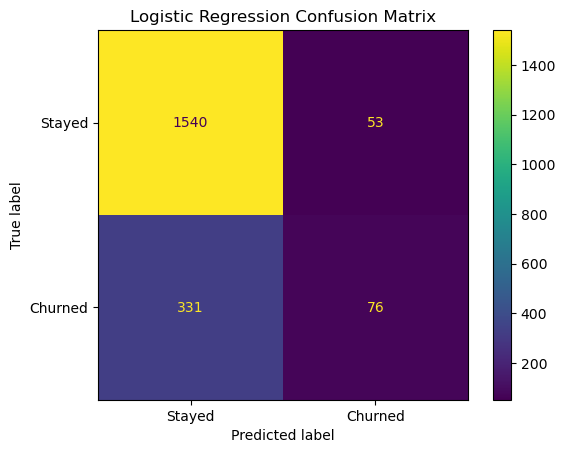

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Decision Tree Classifier

A Decision Tree is a supervised machine learning algorithm that makes predictions using a series of decision rules based on the input features.

In [23]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train the model
decision_tree.fit(X_train, y_train)

# Make predictions
y_pred_tree = decision_tree.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [24]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("=" * 40)
print(f"Accuracy : {accuracy_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall   : {recall_tree:.4f}")
print(f"F1 Score : {f1_tree:.4f}")

Decision Tree Results
Accuracy : 0.8560
Precision: 0.7874
Recall   : 0.4005
F1 Score : 0.5309


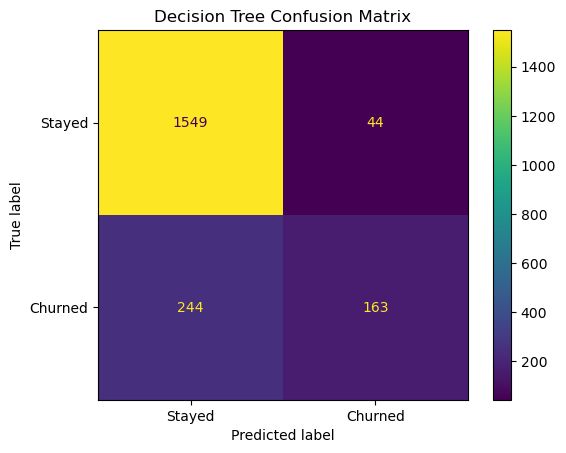

In [25]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

## Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction performance and reduce overfitting.

In [26]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [27]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("=" * 40)
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")

Random Forest Results
Accuracy : 0.8645
Precision: 0.7833
Recall   : 0.4619
F1 Score : 0.5811


## Model Performance Comparison

The performance of the three machine learning models is compared using Accuracy, Precision, Recall, and F1 Score.

In [28]:
# Create a comparison table for all models

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf
    ],
    "Precision": [
        precision_logistic,
        precision_tree,
        precision_rf
    ],
    "Recall": [
        recall_logistic,
        recall_tree,
        recall_rf
    ],
    "F1 Score": [
        f1_logistic,
        f1_tree,
        f1_rf
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8080,0.589147,0.186732,0.283582
1,Decision Tree,0.8560,0.787440,0.400491,0.530945
2,Random Forest,0.8645,0.783333,0.461916,0.581144


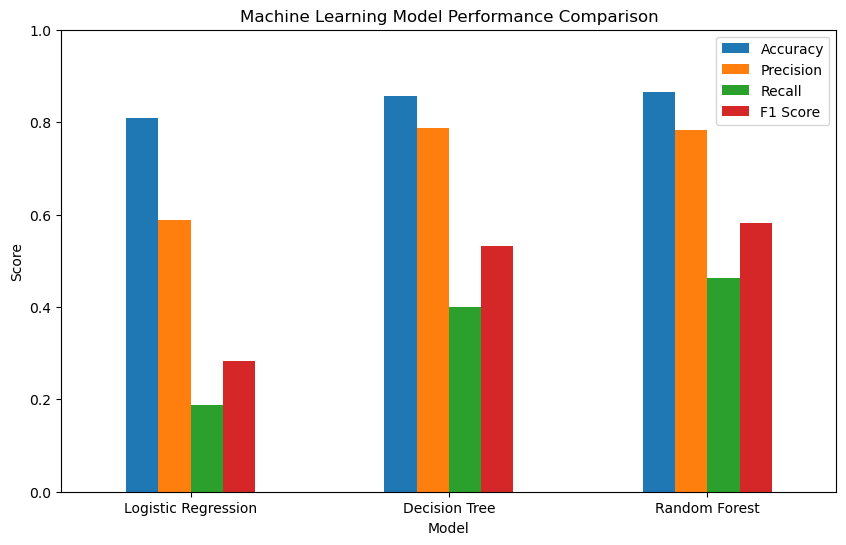

In [29]:
model_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend()
plt.show()

## Feature Importance

Feature importance helps identify which customer characteristics have the greatest influence on the Random Forest churn predictions.

In [30]:
# Calculate feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Age,0.236485
7,EstimatedSalary,0.147016
0,CreditScore,0.142756
3,Balance,0.141756
4,NumOfProducts,0.130410
2,Tenure,0.081817
6,IsActiveMember,0.039933
8,Geography_Germany,0.028923
5,HasCrCard,0.018799
10,Gender_Male,0.018483


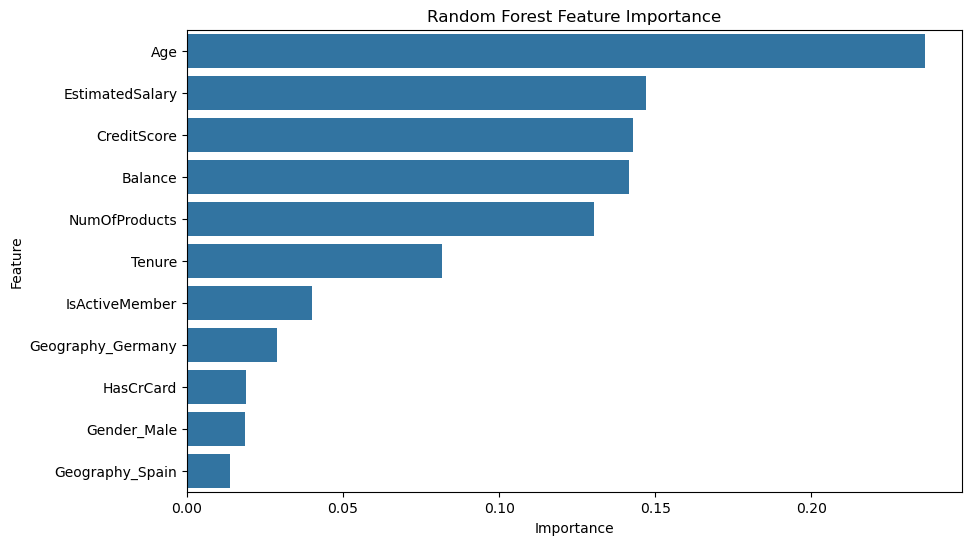

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Customer Churn Prediction

The following function uses the trained Random Forest model to predict whether a new customer is likely to churn.

In [37]:
def predict_customer_churn(
    credit_score,
    geography,
    gender,
    age,
    tenure,
    balance,
    num_of_products,
    has_cr_card,
    is_active_member,
    estimated_salary
):
    # Create customer data
    customer = pd.DataFrame({
        "CreditScore": [credit_score],
        "Geography": [geography],
        "Gender": [gender],
        "Age": [age],
        "Tenure": [tenure],
        "Balance": [balance],
        "NumOfProducts": [num_of_products],
        "HasCrCard": [has_cr_card],
        "IsActiveMember": [is_active_member],
        "EstimatedSalary": [estimated_salary]
    })

    # Encode categorical variables
    customer = pd.get_dummies(
        customer,
        columns=["Geography", "Gender"],
        drop_first=True
    )

    # Make sure customer has the same columns as training data
    customer = customer.reindex(
        columns=X.columns,
        fill_value=0
    )

    # Predict churn
    prediction = random_forest.predict(customer)[0]

    if prediction == 1:
        return "Customer is likely to churn."
    else:
        return "Customer is likely to stay."

In [34]:
result = predict_customer_churn(
    credit_score=650,
    geography="France",
    gender="Female",
    age=40,
    tenure=5,
    balance=50000,
    num_of_products=2,
    has_cr_card=1,
    is_active_member=1,
    estimated_salary=60000
)

print(result)

Customer is likely to stay.


## Business Insights

The customer churn analysis provides useful insights that can help businesses understand customer behavior and identify customers who may be at risk of leaving.

### Key Insights

1. Customer characteristics such as age, geography, credit score, account balance, number of products, and activity status can provide useful information for predicting churn.

2. The exploratory analysis helps identify differences between customers who stayed and customers who exited.

3. Machine learning models can be used to identify customers who may be likely to churn.

4. Feature importance from the Random Forest model helps identify the variables that contribute most to the prediction.

5. Customer churn prediction can help organizations take preventive actions before customers leave.

## Business Recommendations

Based on the analysis, organizations can consider the following actions:

- Identify customers with a high predicted probability of churn.
- Provide personalized offers or services to customers at risk of leaving.
- Improve customer engagement through targeted communication.
- Monitor inactive customers regularly.
- Analyze customer behavior across different geographical regions.
- Use machine learning predictions as a supporting tool for customer retention strategies.

## Conclusion

This project developed a machine learning-based customer churn prediction system using the Churn_Modelling dataset.

The project followed a complete data analytics workflow including data loading, data cleaning, exploratory data analysis, data preprocessing, model training, model evaluation, and customer prediction.

Three machine learning algorithms were implemented: Logistic Regression, Decision Tree, and Random Forest. Their performance was evaluated using Accuracy, Precision, Recall, and F1 Score.

The Random Forest model was also used to identify feature importance and predict whether a new customer is likely to stay or churn.

The project demonstrates how data analytics and machine learning can be used to support customer retention and business decision-making.

## Future Scope

The project can be further improved by:

- Using additional customer behavioral data.
- Performing hyperparameter tuning.
- Testing additional machine learning algorithms.
- Using cross-validation.
- Developing an interactive dashboard.
- Deploying the model as a web or cloud application.
- Updating the model periodically with new customer data.